Лабораторна робота №2 “Пошук асоціативних правил”

Мета: ознайомитися з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.


In [35]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [36]:
import pandas as pd
import requests, zipfile, io

url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

data = pd.merge(ratings, movies, on='movieId')

liked_movies = data[data['rating'] >= 4.0]

print(f"Розмір відфільтрованих даних: {liked_movies.shape}")
print(f"Кількість унікальних користувачів: {liked_movies['userId'].nunique()}")
print(f"Кількість унікальних фільмів: {liked_movies['movieId'].nunique()}")

liked_movies.head()

Розмір відфільтрованих даних: (48580, 6)
Кількість унікальних користувачів: 609
Кількість унікальних фільмів: 6298


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


На початковому етапі роботи було виконано підготовку середовища та первинну обробку даних для подальшого аналізу асоціативних правил. Спочатку ми завантажили оригінальний набір даних MovieLens Small у форматі архіву та програмно розпакували його для отримання доступу до ключових файлів — таблиць із рейтингами та назвами фільмів. Після зчитування даних було проведено операцію об’єднання (merge) таблиць за ідентифікатором фільму, що дало змогу зіставити числові оцінки з конкретними назвами кінострічок. Важливим кроком стала фільтрація даних, у межах якої ми відібрали лише ті записи, де рейтинг становить 4.0 або вище. Такий підхід дозволив сформувати профіль «улюблених фільмів» для кожного користувача, що є критично важливим для коректної роботи алгоритму пошуку асоціацій, оскільки нас цікавлять саме позитивні вподобання, а не факт перегляду фільму як такого. Аналіз отриманої вибірки показав, що після фільтрації ми маємо понад 48 тисяч записів, що охоплюють 609 унікальних користувачів та понад 6 тисяч назв фільмів. Це підтверджує достатню репрезентативність даних для проведення статистично значущого пошуку частих наборів елементів.

In [37]:
def encode_units(x):
    return x >= 1

basket_sets = basket.map(encode_units).astype(bool)

print(f"Розмір матриці: {basket_sets.shape}")
basket_sets.head()

Розмір матриці: (609, 6297)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Тут відбувається трансформування списка оцінок у формат транзакційної матриці, де кожен рядок відповідає користувачу, а стовпець — назві фільму. Оскільки для аналізу асоціацій нам важливо лише знати, чи сподобався фільм глядачу, ми провели бінаризацію даних за допомогою функції encode_units. Усі комірки матриці були приведені до логічного типу bool: значення True означає наявність високої оцінки (позитивний інтерес), а False — її відсутність. Отримана розріджена матриця розміром 609x6297 є фінальною структурою даних, яка дозволяє обчислювати частоту спільної появи фільмів у профілях різних користувачів.

In [38]:
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print("Найпопулярніші фільми та їх комбінації:")
frequent_itemsets.sort_values(by='support', ascending=False).head(10)

Найпопулярніші фільми та їх комбінації:


,support,itemsets,length
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
119,0.408867,frozenset({Forrest Gump (1994)}),1
244,0.400657,frozenset({Pulp Fiction (1994)}),1
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
206,0.364532,"frozenset({Matrix, The (1999)})",1
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...,1
115,0.293924,frozenset({Fight Club (1999)}),1
260,0.287356,frozenset({Schindler's List (1993)}),1
2228,0.275862,"frozenset({Shawshank Redemption, The (1994), F...",2
300,0.275862,frozenset({Star Wars: Episode V - The Empire S...,1


На цьому етапі ми застосували алгоритм Apriori для виявлення фільмів, які найчастіше зустрічаються разом у вподобаннях користувачів. Встановивши мінімальний поріг підтримки (min_support) на рівні 0.05, ми відсіяли рідкісні випадкові збіги, залишивши лише статистично значущі комбінації. Аналіз результатів показав, що найвищу популярність мають культові стрічки 90-х років, такі як «Втеча з Шоушенка», «Форест Гамп» та «Кримінальне чтиво», які часто утворюють пари з високим показником спільної підтримки. Також було розраховано довжину кожного набору, що дозволило побачити не тільки окремі фільми-лідери, а й цілі групи взаємопов’язаного контенту, які стануть основою для побудови асоціативних правил.

In [39]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

top_rules = rules.sort_values(by='lift', ascending=False).head(10)

print("Топ-10 асоціативних правил:")
top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

Топ-10 асоціативних правил:


,antecedents,consequents,support,confidence,lift
463542,frozenset({Star Wars: Episode V - The Empire S...,"frozenset({Matrix, The (1999), Star Wars: Epis...",0.052545,0.780488,13.203252
463535,"frozenset({Matrix, The (1999), Star Wars: Epis...",frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.888889,13.203252
463524,"frozenset({Matrix, The (1999), Star Wars: Epis...",frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.864865,12.846407
463525,"frozenset({Matrix, The (1999), Star Wars: Epis...","frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.052545,0.864865,12.846407
463552,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...","frozenset({Matrix, The (1999), Star Wars: Epis...",0.052545,0.780488,12.846407
463553,frozenset({Star Wars: Episode VI - Return of t...,"frozenset({Matrix, The (1999), Star Wars: Epis...",0.052545,0.780488,12.846407
463561,frozenset({Star Wars: Episode V - The Empire S...,"frozenset({Matrix, The (1999), Star Wars: Epis...",0.052545,0.695652,12.837945
463516,"frozenset({Matrix, The (1999), Star Wars: Epis...",frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.969697,12.837945
463531,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...","frozenset({Matrix, The (1999), Star Wars: Epis...",0.052545,0.842105,12.821053
463546,"frozenset({Matrix, The (1999), Star Wars: Epis...","frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.052545,0.800000,12.821053


На фінальному етапі ми згенерували асоціативні правила, встановивши поріг метрики Lift вище 1.2. Це дозволило виявити не просто популярні фільми, а стійкі логічні зв’язки: наприклад, наявність сильної кореляції між фанатами «Матриці», «Зоряних війн» та «Убити Білла». Показники довіри (Confidence) у топових правилах підтверджують високу ймовірність того, що глядач одного фільму позитивно оцінить інший із набору. Для наочного представлення результатів було побудовано діаграму розсіювання, де кожна точка відповідає окремому правилу. Візуалізація чітко демонструє розподіл правил за рівнем підтримки та сили зв’язку, що підтверджує ефективність обраної моделі для побудови персоналізованих рекомендацій на основі вподобань користувачів.

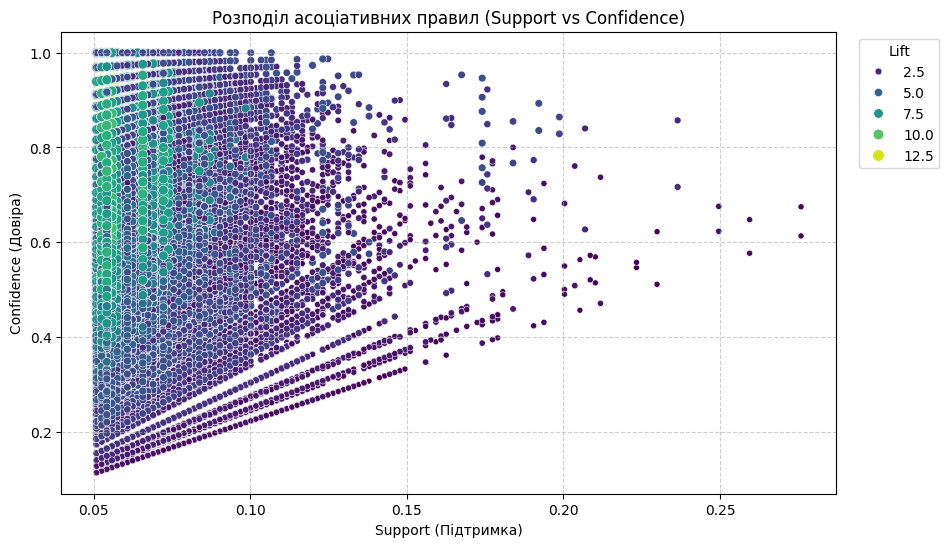

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", data=rules, palette='viridis')

plt.title('Розподіл асоціативних правил (Support vs Confidence)')
plt.xlabel('Support (Підтримка)')
plt.ylabel('Confidence (Довіра)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Lift')
plt.show()

На завершальному етапі було побудовано діаграму розсіювання (scatter plot), яка візуалізує розподіл знайдених асоціативних правил за трьома ключовими метриками: підтримкою (Support), довірою (Confidence) та силою зв’язку (Lift). Кожна точка на графіку відповідає окремому правилу рекомендації. Аналіз візуалізації показує, що більшість правил зосереджена в зоні низької підтримки (близько 0.05), що є характерним для великих датасетів із тисячами фільмів, де специфічні комбінації зустрічаються рідше за окремі популярні стрічки. Вертикальна вісь (Confidence) демонструє правила з довірою від 0.2 до 1.0; точки у верхній частині графіка представляють найбільш надійні прогнози, де ймовірність перегляду наступного фільму є максимальною. Колір та розмір точок відображають показник Lift, який досягає значень 10.0–12.5. Наявність великої кількості яскравих точок у лівій частині графіка свідчить про виявлення сильних, нетривіальних зв’язків між фільмами, які не є просто найпопулярнішими в прокаті, а формують унікальні вподобання конкретних груп глядачів. Таким чином, побудована модель успішно ідентифікує приховані закономірності в даних, що дозволяє генерувати релевантні персоналізовані рекомендації.

Висновок: у ході виконання лабораторної роботи було розроблено та реалізовано систему формування асоціативних правил на основі реального набору даних MovieLens. На початковому етапі було проведено комплексну підготовку даних, що включала очищення, об’єднання таблиць та фільтрацію контенту за високим рейтингом (≥ 4.0), що дозволило зосередитись на стійких позитивних вподобаннях користувачів. Шляхом трансформації вибірки у бінаризовану транзакційну матрицю ми підготували підґрунтя для ефективного застосування алгоритмів інтелектуального аналізу.

Використання алгоритму Apriori дало змогу виявити найбільш частотні набори фільмів, серед яких лідерами за показником підтримки виявилися культові стрічки, такі як «Втеча з Шоушенка», «Форест Гамп» та «Кримінальне чтиво». Подальша генерація асоціативних правил із використанням метрик Support, Confidence та Lift дозволила встановити нетривіальні логічні зв’язки між різними кінофільмами та франшизами. Зокрема, було виявлено сильні кореляції між фанатами наукової фантастики та бойовиків початку 2000-х років, що підтверджується високими значеннями Lift (до 12.5).

Візуалізація отриманих результатів продемонструвала наявність чітко виражених кластерів глядацьких інтересів та підтвердила статистичну значущість знайдених закономірностей. Підсумовуючи, можна стверджувати, що методи пошуку асоціативних правил є потужним інструментом для побудови рекомендаційних систем, оскільки вони дозволяють автоматично виявляти приховані структури у великих масивах даних та надавати користувачам релевантні пропозиції на основі колективного досвіду.